In [ ]:
from collections import defaultdict
import torch
from tqdm.auto import tqdm
from matplotlib import pyplot as plt
import random
from torch.utils.data import DataLoader
from methylseqnet.dataset import MultiMethylDataset, BaseHDF5Dataset
from methylseqnet.transforms import EncodingSelector
from methylseqnet.peaks import selected_peaks_from_target
from methylseqnet_repro.paths import preprocessed_datasets

In [2]:
dataset = MultiMethylDataset(
    preprocessed_datasets / "atlas" / "fold0.h5",)
interp_layer = EncodingSelector(encoding_str="interp-methyl-only")
cpg_density_layer = EncodingSelector(encoding_str="cpg-density-only")
dataloader = DataLoader(dataset, batch_size=1, num_workers=16)
io_mappings_df = dataset.get_io_mappings_df()

  0%|          | 0/200 [00:00<?, ?it/s]

Blood-B-Mem: cpg density mean at peaks: 0.0613, non-peaks: 0.0167
Breast-Basal-Epithel: cpg density mean at peaks: 0.0612, non-peaks: 0.0167
Pancreas-Beta: cpg density mean at peaks: 0.0608, non-peaks: 0.0167
Lung-Bronchus-Epithel: cpg density mean at peaks: 0.0587, non-peaks: 0.0167
Bronchus-Smooth-Muscle: cpg density mean at peaks: 0.0570, non-peaks: 0.0168
Heart-Cardiomyocyte: cpg density mean at peaks: 0.0602, non-peaks: 0.0168


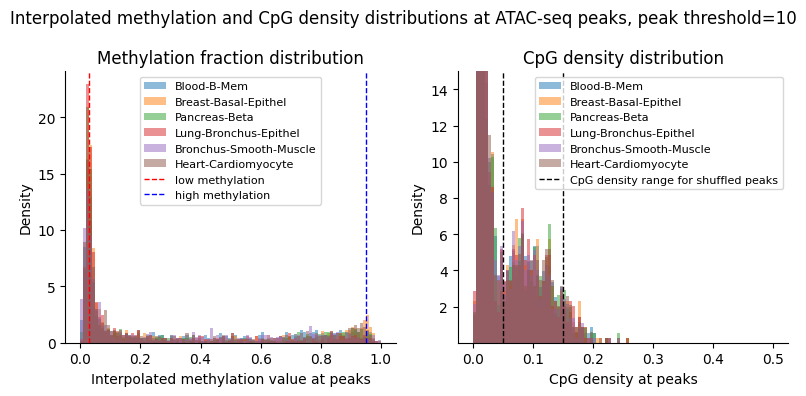

In [6]:
methyl_track_dict = defaultdict(list)
methyl_track_peaks_dict = defaultdict(list)
methyl_track_nonpeaks_dict = defaultdict(list)
cpg_track_dict = defaultdict(list)
cpg_track_peaks_dict = defaultdict(list)
cpg_track_nonpeaks_dict = defaultdict(list)
peak_threshold = 10
non_peak_threshold = 1
num_samples = 200
extra_bins_per_peak = 2048//128
cell_types = io_mappings_df[io_mappings_df['data_type']=='ATAC-seq']['cell_type'].tolist()[7:13]
fig, axs = plt.subplots(1,2, figsize=(8,4))
for sample in tqdm(dataloader,total=num_samples):
    for cell_type in cell_types:
        interpolated_methylation = interp_layer(torch.cat([sample['sequence'][:,0,:,:],sample['conditioning_state'][:,0,cell_type,:,:]], dim=1))
        cpg_density = cpg_density_layer(torch.cat([sample['sequence'][:,0,:,:],sample['conditioning_state'][:,0,cell_type,:,:]], dim=1))
        binned_methylation = torch.nn.functional.avg_pool1d(interpolated_methylation,kernel_size=128,stride=128)
        binned_cpg_density = torch.nn.functional.avg_pool1d(cpg_density,kernel_size=128,stride=128)
        methyl_track_dict[cell_type].append(binned_methylation)
        cpg_track_dict[cell_type].append(binned_cpg_density)
        # cell_type_to_select = cell_type
        cell_type_to_select = random.choice(cell_types)
        target_channel_idx = io_mappings_df[(io_mappings_df['cell_type']==cell_type_to_select) & (io_mappings_df['data_type']=='ATAC-seq')]['channel'].tolist()
        # target_channel_idx = io_mappings_df[io_mappings_df['data_type']=='ATAC-seq']['channel'].tolist()
        target = sample['target'][:,0,target_channel_idx,:].mean(dim=1).squeeze().numpy()
        peaks = selected_peaks_from_target(target, peak_threshold=peak_threshold, min_peak_distance_bins=128)
        expanded_peaks = [
            [
                expanded_peak for expanded_peak in range(max(0, peak - extra_bins_per_peak//2), 
                                                             min(len(target), peak + extra_bins_per_peak//2))
            ] for peak in peaks]      
        # print(peaks)
        peak_methylation = binned_methylation[0,0,peaks]
        peak_cpg_density = torch.tensor([binned_cpg_density[0,0,expanded_peak].mean() for expanded_peak in expanded_peaks])
        non_peaks = (target < (non_peak_threshold)).nonzero()[0]
        non_peak_methylation = binned_methylation[0,0,non_peaks]
        non_peak_cpg_density = binned_cpg_density[0,0,non_peaks]
        methyl_track_peaks_dict[cell_type].append(peak_methylation)
        methyl_track_nonpeaks_dict[cell_type].append(non_peak_methylation)
        cpg_track_peaks_dict[cell_type].append(peak_cpg_density)
        cpg_track_nonpeaks_dict[cell_type].append(non_peak_cpg_density)
    if len(methyl_track_dict[cell_type]) >= num_samples:
        break
for cell_type in cell_types:
    cell_type_name = io_mappings_df[io_mappings_df['cell_type']==cell_type]['methylation_files'].values[0][2:-2]
    methyl_cat = torch.cat(methyl_track_dict[cell_type],dim=2).squeeze().numpy()
    peak_methyl_cat = torch.cat(methyl_track_peaks_dict[cell_type],dim=0).squeeze().numpy()
    non_peak_methyl_cat = torch.cat(methyl_track_nonpeaks_dict[cell_type],dim=0).squeeze().numpy()
    cpg_cat = torch.cat(cpg_track_dict[cell_type],dim=2).squeeze().numpy()
    peak_cpg_cat = torch.cat(cpg_track_peaks_dict[cell_type],dim=0).squeeze().numpy()
    non_peak_cpg_cat = torch.cat(cpg_track_nonpeaks_dict[cell_type],dim=0).squeeze().numpy()
    # axs[0,0].hist(methyl_cat.flatten(), bins=100, range=(0,1), alpha=0.5, label=cell_type_name, density=True)
    axs[0].hist(peak_methyl_cat.flatten(), bins=100, range=(0,1), alpha=0.5, label=cell_type_name, density=True)
    # axs[0,2].hist(non_peak_methyl_cat.flatten(), bins=100, range=(0,1), alpha=0.5, label=cell_type_name, density=True)
    # axs[1,0].hist(cpg_cat.flatten(), bins=100, range=(0,0.5), alpha=0.5, label=cell_type_name, density=True)
    # axs[1,0].set_yscale('log')
    # axs[1,0].set_ylim(1e-4,15)
    axs[1].hist(peak_cpg_cat.flatten(), bins=100, range=(0,0.5), alpha=0.5, label=cell_type_name, density=True)
    # axs[1,1].set_yscale('log')
    axs[1].set_ylim(1e-4,15)
    # axs[1,2].hist(non_peak_cpg_cat.flatten(), bins=100, range=(0,0.5), alpha=0.5, label=cell_type_name, density=True)
    # axs[1,2].set_yscale('log')
    # axs[1,2].set_ylim(1e-4,15)
    print(f"{cell_type_name}: cpg density mean at peaks: {peak_cpg_cat.mean():.4f}, non-peaks: {non_peak_cpg_cat.mean():.4f}")
fig.suptitle(f"Interpolated methylation and CpG density distributions at ATAC-seq peaks, peak threshold={peak_threshold}")
# axs[0,0].axvline(0.03, color='k', linestyle='dashed', linewidth=1)
# axs[0,0].axvline(0.25, color='k', linestyle='dashed', linewidth=1)
# axs[0,0].axvline(0.5, color='k', linestyle='dashed', linewidth=1)
# axs[0,0].axvline(0.75, color='k', linestyle='dashed', linewidth=1)
# axs[0,0].axvline(0.95, color='k', linestyle='dashed', linewidth=1)
# axs[0,0].set_xlabel("Interpolated methylation value")
# axs[0,0].set_ylabel("Density")
# axs[0,0].set_title(f"{len(methyl_cat):e} random 128bp bins")
axs[0].axvline(0.03, color='red', linestyle='dashed', linewidth=1, label="low methylation")
# axs[0].axvline(0.25, color='k', linestyle='dashed', linewidth=1)
# axs[0].axvline(0.5, color='k', linestyle='dashed', linewidth=1)
# axs[0].axvline(0.75, color='k', linestyle='dashed', linewidth=1)
axs[0].axvline(0.95, color='blue', linestyle='dashed', linewidth=1, label="high methylation")
axs[0].legend(fontsize=8)
axs[0].spines['top'].set_visible(False)
axs[0].spines['right'].set_visible(False)
axs[0].set_xlabel("Interpolated methylation value at peaks")
axs[0].set_ylabel("Density")
axs[0].set_title(f"Methylation fraction distribution")
# axs[0,2].axvline(0.03, color='k', linestyle='dashed', linewidth=1)
# axs[0,2].axvline(0.25, color='k', linestyle='dashed', linewidth=1)
# axs[0,2].axvline(0.5, color='k', linestyle='dashed', linewidth=1)
# axs[0,2].axvline(0.75, color='k', linestyle='dashed', linewidth=1)
# axs[0,2].axvline(0.95, color='k', linestyle='dashed', linewidth=1)
# axs[0,2].set_xlabel("Interpolated methylation value at non-peaks")
# axs[0,2].set_ylabel("Density")
# axs[0,2].set_title(f"{len(non_peak_methyl_cat):e} non-peak bins <={non_peak_threshold} counts")
# axs[1,0].set_xlabel("CpG density")
# axs[1,0].set_ylabel("Density")
# axs[1,0].set_title(f"{len(cpg_cat):e} random 128bp bins")
axs[1].axvline(0.05, color='k', linestyle='dashed', linewidth=1, label="CpG density range for shuffled peaks")
axs[1].axvline(0.15, color='k', linestyle='dashed', linewidth=1,)
axs[1].set_xlabel("CpG density at peaks")
axs[1].set_ylabel("Density")
axs[1].set_title(f"CpG density distribution")
axs[1].legend(fontsize=8)
axs[1].spines['top'].set_visible(False)
axs[1].spines['right'].set_visible(False)
# axs[1,2].set_xlabel("CpG density at non-peaks")
# axs[1,2].set_ylabel("Density")
# axs[1,2].set_title(f"{len(non_peak_cpg_cat):e} non-peak bins <={non_peak_threshold} counts")
plt.tight_layout()
fig.savefig("pdfs/supplement__motif_insertion_methylation_cpg_density_distributions_atac_peaks.pdf")
plt.show()

Text(0.5, 1.0, '7.689040e+05 non-peak bins <=1 counts')

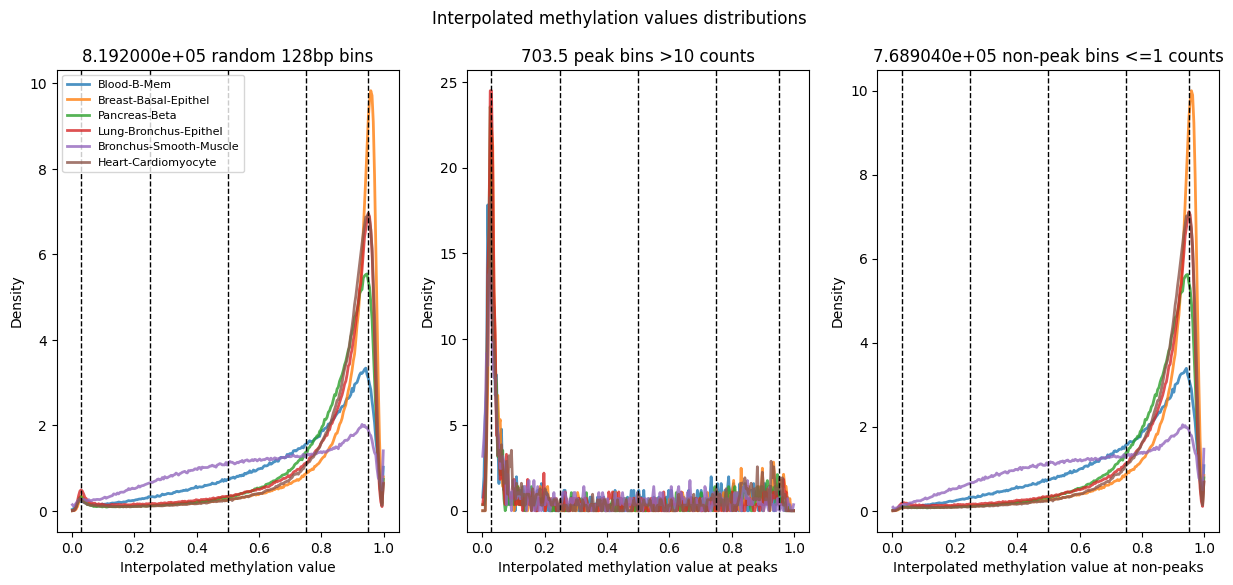

In [4]:
from matplotlib.collections import PolyCollection
import numpy as np

fig, axs = plt.subplots(1,3, figsize=(15,6))
fig.suptitle("Interpolated methylation values distributions")

peak_bins_ct = 0
nonpeak_bins_ct = 0

for cell_type in cell_types:
    cell_type_name = io_mappings_df[io_mappings_df['cell_type']==cell_type]['methylation_files'].values[0][2:-2]
    methyl_cat = torch.cat(methyl_track_dict[cell_type],dim=2).squeeze().numpy()
    peak_methyl_cat = torch.cat(methyl_track_peaks_dict[cell_type],dim=0).squeeze().numpy()
    non_peak_methyl_cat = torch.cat(methyl_track_nonpeaks_dict[cell_type],dim=0).squeeze().numpy()

    peak_bins_ct += peak_methyl_cat.shape[0]
    nonpeak_bins_ct += non_peak_methyl_cat.shape[0]
    
    hist, bins = np.histogram(methyl_cat.flatten(), bins=250, range=(0,1), density=True)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    axs[0].plot(bin_centers, hist, label=cell_type_name, linewidth=2, alpha=0.8)
    hist_peaks, bins_peaks = np.histogram(peak_methyl_cat.flatten(), bins=250, range=(0,1), density=True)
    bin_centers_peaks = (bins_peaks[:-1] + bins_peaks[1:]) / 2
    axs[1].plot(bin_centers_peaks, hist_peaks, label=cell_type_name, linewidth=2, alpha=0.8)
    hist_nonpeaks, bins_nonpeaks = np.histogram(non_peak_methyl_cat.flatten(), bins=250, range=(0,1), density=True)
    bin_centers_nonpeaks = (bins_nonpeaks[:-1] + bins_nonpeaks[1:]) / 2
    axs[2].plot(bin_centers_nonpeaks, hist_nonpeaks, label=cell_type_name, linewidth=2, alpha=0.8)


setpoints = [0.03, 0.25, 0.5, 0.75, 0.95]
for setpoint in setpoints:
    axs[0].axvline(setpoint, color='k', linestyle='dashed', linewidth=1)
    axs[1].axvline(setpoint, color='k', linestyle='dashed', linewidth=1)
    axs[2].axvline(setpoint, color='k', linestyle='dashed', linewidth=1)

axs[0].legend(fontsize=8)
axs[0].set_xlabel("Interpolated methylation value")
axs[0].set_ylabel("Density")
axs[0].set_title(f"{len(methyl_cat):e} random 128bp bins")
axs[1].set_xlabel("Interpolated methylation value at peaks")
axs[1].set_ylabel("Density")
axs[1].set_title(f"{peak_bins_ct/len(cell_types)} peak bins >{peak_threshold} counts")
axs[2].set_xlabel("Interpolated methylation value at non-peaks")
axs[2].set_ylabel("Density")
axs[2].set_title(f"{nonpeak_bins_ct/len(cell_types):e} non-peak bins <={non_peak_threshold} counts")